# Spam Email/Message Detection

In [1]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [3]:
df = df[["v1", "v2"]]
df.columns = ["label", "text"]

In [4]:
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    df["text"], df["label_num"], test_size=0.2, random_state=42
)

In [6]:
vectorizer = TfidfVectorizer(stop_words="english")
x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

In [7]:
model = MultinomialNB()
model.fit(x_train_vec, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [9]:
y_pred = model.predict(x_test_vec)
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.9668161434977578


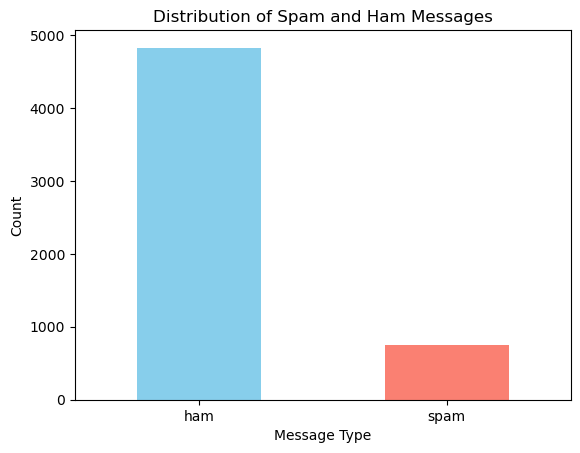

In [10]:
df["label"].value_counts().plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [11]:
joblib.dump(model, "spam_model.pkl")
joblib.dump(vectorizer, "spam_vectorizer.pkl")

['spam_vectorizer.pkl']